In [377]:
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np, pandas as pd, scipy as sci, cmasher as cmr, os
from sklearn.preprocessing import StandardScaler
# plot function consts
FILE = "volcanoB"
fpath = lambda x: "E:/Repositories/physicstools/volcano/" + x + ".csv"
cols = ['vent size', 'gas mass frac', 'velocity', 'indep', 'lo','hi']
pcols =['vent size','gas mass frac', 'velocity', 'indep', 'bound','color']
def normalmk():
    df = pd.read_csv(fpath(FILE))
    df_proc = df.copy()
    df_proc = df_proc[df_proc.columns[0:7]]
    for ind, row in df_proc.iterrows():
        if row['modified gp'] != 0 and row['modified gp'] != '0':
            df_proc.at[ind, 'gas percentage'] = row['modified gp']
    df_proc = df_proc.drop(columns=['modified gp'])
    df_proc.columns = cols
    df_proc = df_proc.reset_index(drop=True)
    df_proc = df_proc.replace('always', np.nan)
    df_proc = df_proc.dropna()
    # vent size, gas mass fraction, velocity, indep, i1, i2
    # rand(1-5000), rand(0-1), rand(1-500), rand(vent size, gas mass fraction, velocity), lower bound, upper bound --> (of indep)
    # generate points, if has i1 and i2, generate points (x,y,z) where x,y,z are consts in first 3 cols, and replace i1 and i2 with the col in indep
    gen_points = [[],[],[],[],[],[]]
    gen_mids = [[],[],[],[]]
    for ind,row in df_proc.iterrows():
        indepi = pcols.index(row['indep'])
        if isinstance(row['lo'], str) or isinstance(row['hi'], str): continue 
        for b in ('lo','hi'):
            const = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep'], 0 if b == 'lo' else 1, 'blue' if b == 'lo' else 'red']
            const[indepi] = row[b]
            _ = [gen_points[i].append(vtype(const[i])) for i,vtype in enumerate((float,float,float,str,int,str))]
            const2 = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep']]
            const2[indepi] = (float(row['lo']) + float(row['hi']))/2
            _ = [gen_mids[i].append(vtype(const2[i])) for i,vtype in enumerate((float,float,float,str))]
    df_lims = pd.DataFrame(gen_points).T 
    df_lims.columns = pcols 
    df_mids = pd.DataFrame({k:gen_mids[i] for i,k in enumerate(pcols[0:4])})
    lims = {k:(df_lims[i].min(), df_lims[i].max()) for k,i in zip(('vsz','gmf','svl'), cols[0:3])}
    return df_proc, df_lims, df_mids,lims
def extremesmk(lims='minmax'):
    df = pd.read_csv(fpath(FILE))
    df_proc = df.copy()
    df_proc = df_proc[df_proc.columns[0:7]]
    for ind, row in df_proc.iterrows():
        if row['modified gp'] != 0 and row['modified gp'] != '0':
            df_proc.at[ind, 'gas percentage'] = row['modified gp']
    df_proc = df_proc.drop(columns=['modified gp'])
    df_proc.columns = cols
    df_proc = df_proc.reset_index(drop=True)
    # first extract correct lims
    df_proc_clean = df_proc.replace(['always','posinf','neginf'], np.nan).dropna()
    gen_points_clean = [[],[],[],[],[],[]]
    gen_mids_clean = [[],[],[],[]]
    for ind,row in df_proc_clean.iterrows():
        indepi = pcols.index(row['indep'])
        for b in ('lo','hi'):
            const = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep'], 0 if b == 'lo' else 1, 'blue' if b == 'lo' else 'red']
            const[indepi] = row[b]
            _ = [gen_points_clean[i].append(vtype(const[i])) for i,vtype in enumerate((float,float,float,str,int,str))]
            const2 = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep']]
            const2[indepi] = (float(row['lo']) + float(row['hi']))/2
            _ = [gen_mids_clean[i].append(vtype(const2[i])) for i,vtype in enumerate((float,float,float,str))]
    df_lims = pd.DataFrame(gen_points_clean).T 
    df_lims.columns = pcols 
    df_mids = pd.DataFrame({k:gen_mids_clean[i] for i,k in enumerate(pcols[0:4])})
    rlims = {i:(-np.inf, np.inf) for i in cols[0:3]} if lims == 'infs' else {i:(df_lims[i].min(), df_lims[i].max()) for i in cols[0:3]} 
    lims = {k:(df_lims[i].min(), df_lims[i].max()) for k,i in zip(('vsz','gmf','svl'), cols[0:3])}

    # now remake the df_proc, taking into account the new lims, such that neginf --> min_i or -np.inf, posinf --> max_i or np.inf, always --> np.nan (to be dropped)
    df_proc = df_proc.replace('always', np.nan).dropna()
    gen_points = [[],[],[],[],[],[]]
    gen_mids = [[],[],[],[]]
    for ind,row in df_proc.iterrows():
        indepi = pcols.index(row['indep'])
        for b in ('lo','hi'):
            row[b]= rlims[row['indep']][0] if row[b] == 'neginf' else rlims[row['indep']][1] if row[b] == 'posinf' else row[b]
        for b in ('lo','hi'):
            
            const = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep'], 0 if b == 'lo' else 1, 'blue' if b == 'lo' else 'red']
            const[indepi] = row[b]
            _ = [gen_points[i].append(vtype(const[i])) for i,vtype in enumerate((float,float,float,str,int,str))]
        const2 = [row['vent size'], row['gas mass frac'], row['velocity'], row['indep']]
        const2[indepi] = (float(row['lo']) + float(row['hi']))/2
        _ = [gen_mids[i].append(vtype(const2[i])) for i,vtype in enumerate((float,float,float,str))]
    df_lims = pd.DataFrame(gen_points).T 
    df_lims.columns = pcols 
    df_mids = pd.DataFrame({k:gen_mids[i] for i,k in enumerate(pcols[0:4])})
    return df_proc, df_lims, df_mids, lims
# Naming convention::::
#               V->vsz -> Vent SiZe         -> vent size        
#               S->svl -> Source VeLocity   -> velocity        
#               G->gmf -> Gas Mass Fraction -> gas mass frac
#
#               gridVG_gmf -> grid of X=vent size, Y=gas mass frac containing gas mass frac (as its also the Y axis, the grid is just a meshgrid)  )
# quantity limits, labels, formatters, locations, colors, colormaps.

def quals_(lims):
    quals=dict(
    vsz=dict(lims=lims['vsz'], c='vent size', label='Vent Radius (m)',fmt=lambda x,p:f"{np.round((x/1000*(lims['vsz'][1]-lims['vsz'][0])+lims['vsz'][0])/100)*100 :.0f}", loc=200,cmap=cmr.cosmic,ticks=[[1,*np.linspace(1000,5000,5,endpoint=True)],["1",]+[f"{int(i)}" for i in np.linspace(1000,5000,5,endpoint=True)]]),
    gmf=dict(lims=lims['gmf'], c='gas mass frac', label='Gas Mass Fraction',fmt=lambda x,p:f"{x/1000*(lims['gmf'][1]-lims['gmf'][0])+lims['gmf'][0]:.2f}",loc=(0.02/lims['gmf'][1]*1000),cmap=cmr.emerald,ticks=[[4e-05, *np.linspace(0.02,0.14,7,endpoint=True),0.1515],["4e-5",]+[f"{i:.2f}" for i in np.linspace(0.02,0.14,7,endpoint=True)]+["0.1515",]]),
    svl=dict(lims=lims['svl'], c='velocity', label='Source Velocity (m/s)',fmt=lambda x,p:f"{np.round((x/1000*(lims['svl'][1]-lims['svl'][0])+lims['svl'][0])/10)*10:.0f}",loc=200,cmap=cmr.ember,ticks=[[1,*np.linspace(100,500,5,endpoint=True)],["1",]+[f"{int(i)}" for i in np.linspace(100,500,5,endpoint=True)]]))
    return quals
def gs_(gridVG_vsz, gridVG_gmf, gridVG_svl,gridSV_svl, gridSV_vsz, gridSV_gmf,gridGS_gmf, gridGS_svl, gridGS_vsz):
    return [
    dict(x=dict(v=gridVG_vsz, **quals['vsz']),y=dict(v=gridVG_gmf, **quals['gmf']),z=dict(v=gridVG_svl, **quals['svl']),),
    dict(x=dict(v=gridSV_svl, **quals['svl']),y=dict(v=gridSV_vsz, **quals['vsz']),z=dict(v=gridSV_gmf, **quals['gmf']),),
    dict(x=dict(v=gridGS_gmf, **quals['gmf']),y=dict(v=gridGS_svl, **quals['svl']),z=dict(v=gridGS_vsz, **quals['vsz']),)
    ]
def altcontours_(gs):
    altcontours_v1={'x':gs[0].values(),'y':gs[1].values(),'z':gs[2].values()}
    altcontours_v2={'z':gs[0].values(),'y':gs[1].values(),'x':gs[2].values()}
    return altcontours_v1, altcontours_v2
shplots = dict(gridspec_kw={'height_ratios': [0.5, 2], 'width_ratios': [2, 0.5], 'wspace':0.1, 'hspace':0.1}, sharex='col', sharey='row')
defaults={
        'scatter':dict(zorder=4),
        'plot_trisurf':dict(color='white',alpha=0.5,zorder=2),
        'plot_surface':dict(alpha=0.5, edgecolor='black', color='grey',zorder=2),
        'contour':dict(offset=0,stride=10,zorder=0.5),
        'contourf':dict(offset=0,stride=10,zorder=0.5,levels=7),
        'clabel':dict(inline=True, fontsize=8,manual=False, inline_spacing=2),
        'interp_grid':dict(method='linear'),
        'interp_rbf':dict(smoothing=0.3, kernel='thin_plate_spline', epsilon=0.1),
        'wireframe':dict(color='black',zorder=2, linewidth=0.5, alpha=0.9),
    }
def kwupdated(kws, defkey):
    if not isinstance(kws,dict): return defaults[defkey]
    else: 
        kws_ = defaults[defkey].copy()
        kws_.update(kws)
        return kws_  
def interpolator(xs,ys,zs,mode='grid',norm=True, **kwargs):
    """
        Interpolates data based on the given x, y, and z parameters.
        Parameters:
        xs (str): The key for the x-axis data in the 'quals' dictionary.
        ys (str): The key for the y-axis data in the 'quals' dictionary.
        zs (str): The key for the z-axis data in the 'quals' dictionary.
        mode (str, optional): The interpolation mode, either 'grid' or 'rbf'. Defaults to 'grid'.
        norm (bool, optional): Whether to normalize the data before interpolation. Defaults to True.
        **kwargs: Additional keyword arguments for the interpolation method.
        Returns:
        tuple: A tuple containing the interpolated x, y grid (xx, yy) and the interpolated z values (zz).
    """
    xx,yy =np.mgrid[quals[xs]['lims'][0]:quals[xs]['lims'][1]:1000j,quals[ys]['lims'][0]:quals[ys]['lims'][1]:1000j] # x,y=vent size, gas mass frac
    kws = kwupdated(kwargs, 'interp_rbf') if mode == 'rbf' else kwupdated(kwargs, 'interp_grid')
    if mode == 'rbf': 
        dfin = df_mids.drop_duplicates(subset=[quals[xs]['c'], quals[ys]['c']])
    else:
        dfin = df_mids
    xyv = dfin[[quals[xs]['c'], quals[ys]['c']]].values
    zv = dfin[quals[zs]['c']].values
    xxyy = np.column_stack([xx.ravel(), yy.ravel()])
    if norm:
        scaler = StandardScaler()
        xyv = scaler.fit_transform(xyv)
        xxyy = scaler.transform(xxyy)
        z_scaler = StandardScaler()
        zv = z_scaler.fit_transform(zv.reshape(-1, 1)).flatten()  # Ensure proper shape

    if mode == 'grid':
        zz = sci.interpolate.griddata(xyv, zv, xxyy,**kws).reshape(xx.shape)
    elif mode == 'rbf':
        rbf = sci.interpolate.RBFInterpolator(xyv, zv,**kws)
        zz = rbf(xxyy).reshape(xx.shape)
    if norm:
        zz = z_scaler.inverse_transform(zz)
    zz = np.clip(zz, quals[zs]['lims'][0], quals[zs]['lims'][1])
    return xx,yy,zz 
          
# plot and fig functions
# 3d plots
def p_3d(ax3d,x,y,z,sets=dict(),cmap='coolwarm',**kwargs):
    """
        Plots a 3D plot with specified axis info and formatting.
        Parameters:
        x,y,z (dict): Dictionary containing axis info.
        sets (dict, optional): Additional settings to apply to the plot. Default is an empty dictionary.
        cmap (str, optional): Colormap to use for the plot. Default is 'coolwarm'.
        **kwargs: Additional keyword arguments to pass to the plot.
        Returns:
        tuple: The figure and 3D axes objects.
    """
    if isinstance(cmap, str):
        cmap=[cmap,cmap,cmap]
    if "scatter" in kwargs:
        kws = kwupdated(kwargs['scatter'],'scatter')
        ax3d.scatter(df_lims[x['c']],df_lims[y['c']],df_lims[z['c']], c=df_lims['color'], **kws)
    if "plot_trisurf" in kwargs:
        kws = kwupdated(kwargs['plot_trisurf'],'plot_trisurf')
        ax3d.plot_trisurf(df_mids[x['c']],df_mids[y['c']],df_mids[z['c']], **kws)
    if "plot_surface" in kwargs:
        kws = kwupdated(kwargs['plot_surface'],'plot_surface')
        ax3d.plot_surface(x['v'],y['v'],z['v'], **kws)
    if "contour" in kwargs or "contourf" in kwargs:
        if "altcontour" in kwargs:v = altcontours_(gs)[kwargs['altcontour']]
        else:v = dict(x=[x['v'],y['v'],z['v']],y=[x['v'],y['v'],z['v']],z=[x['v'],y['v'],z['v']])     
    if "contour" in kwargs:
        kws = kwupdated(kwargs['contour'],'contour')
        cx,cy,cz = [ax3d.contour(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]
    if "contourf" in kwargs:
        kws = kwupdated(kwargs['contourf'],'contourf')
        cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]
    if "wireframe" in kwargs:
        kws = kwupdated(kwargs['wireframe'],'wireframe')
        ax3d.plot_wireframe(x['v'],y['v'],z['v'], **kws)  
    ax3d.set(xlim=x['lims'],ylim=y['lims'],zlim=z['lims'], xlabel=x['label'],ylabel=y['label'],zlabel=z['label'],**sets)
    ax3d.set_zlabel(z['label'])
    ax3d.xaxis.set_ticks(ticks=x['ticks'][0],labels=x['ticks'][1])
    ax3d.yaxis.set_ticks(ticks=y['ticks'][0],labels=y['ticks'][1])
    ax3d.zaxis.set_ticks(ticks=z['ticks'][0],labels=z['ticks'][1])
    return ax3d
# 2d plots
def p_im(ax,x,y,z,cmap='viridis',color_exts=None,cmapor=dict(location='right',shrink=0.7), **kwargs):
    """
        Plots an image on the given axes with specified colormap and formatting.
        Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the image.
        x,y,z (dict): Dictionary containing axis info.
        cmap (str, optional): Colormap to use for the image. Default is 'viridis'.
        color_exts (optional): Not used in the current implementation.
        cmapor (str, optional): Orientation of the colorbar. Default is 'horizontal'.
        Returns:
        tuple: The image and colorbar objects.
    """
    
    cmap = mpl.colormaps.get_cmap(cmap)
    norm = mpl.colors.Normalize(vmin=z['lims'][0],vmax=z['lims'][1])
    if color_exts is not None:
        cmap.set_over(color_exts[1])
        cmap.set_under(color_exts[0])
        cmap.set_bad(color_exts[2])
    im =ax.imshow(z['v'].T,  cmap=cmap,origin='lower', norm=norm)
    ax.set(xlabel=x['label'],ylabel=y['label'])
    if cmapor:
        cbar = plt.colorbar(im,ax=ax, **cmapor)
        cbar.set_label(z['label'])
        print(z['ticks'][0],z['ticks'][1])
        cbar.set_ticks(ticks=z['ticks'][0],labels=z['ticks'][1])
    xticks_,yticks_ = ticks=x['ticks'][0],y['ticks'][0]
    xticks = [xt/x['lims'][1]*1000 for xt in xticks_]
    yticks = [yt/y['lims'][1]*1000 for yt in yticks_]
    ax.xaxis.set_ticks(ticks=xticks,labels=x['ticks'][1])
    ax.yaxis.set_ticks(ticks=yticks,labels=y['ticks'][1])
    return im,cbar
def p_cont(ax,x,y,z,cmap='inferno',clabel=True,cmapor=False, **kwargs):
    """
        Plots contours on the given axes with specified colormap and formatting.
        Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the contours.
        x,y,z (dict): Dictionary containing axis info.
        cmap (str, optional): Colormap to use for the contours. Default is 'inferno'.
        clabels (bool, optional): Whether to plot contour labels. Default is True.
        Returns:
        tuple: The contour and contour label objects.
    """
    cmap = mpl.colormaps.get_cmap(cmap)
    norm = mpl.colors.Normalize(vmin=z['lims'][0],vmax=z['lims'][1])
    ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
    ctlab = ax.clabel(ctr,**kwupdated(clabel,'clabel')) if clabel else None
    ax.set(xlabel=x['label'],ylabel=y['label'])
    if cmapor:
        cbar = plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm),ax=ax, **cmapor)
        cbar.set_label(z['label'])
        cbar.set_ticks(ticks=z['ticks'][0],labels=z['ticks'][1])
    ax.xaxis.set_ticks(ticks=x['ticks'][0],labels=x['ticks'][1])
    ax.yaxis.set_ticks(ticks=y['ticks'][0],labels=y['ticks'][1])
    return ctr, ctlab
def p_contf(ax,x,y,z,cmap='inferno',clabel=True,cmapor=False, **kwargs):
    """
        Plots filled contours on the given axes with specified colormap and formatting.
        Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the filled contours.
        x,y,z (dict): Dictionary containing axis info.
        cmap (str, optional): Colormap to use for the filled contours. Default is 'inferno'.
        clabels (bool, optional): Whether to plot contour labels. Default is True.
        Returns:
        tuple: The filled contour and contour label objects.
    """

    ctrf = ax.contourf(x['v'],y['v'],z['v'], cmap=cmap, **kwupdated(kwargs,'contourf'))
    ctlab = ax.clabel(ctrf, **kwupdated(clabel,'clabel')) if clabel else None
    ax.set(xlabel=x['label'],ylabel=y['label'])
    if cmapor:
        cbar = plt.colorbar(ctrf,ax=ax, **cmapor)
        cbar.set_label(z['label'])
        cbar.set_ticks(ticks=z['ticks'][0],labels=z['ticks'][1])
    ax.xaxis.set_ticks(ticks=x['ticks'][0],labels=x['ticks'][1])
    ax.yaxis.set_ticks(ticks=y['ticks'][0],labels=y['ticks'][1])
    return ctrf, ctlab
def p_scatterlims(ax,x,y,z, **kwargs):
    """
        Plots a scatter plot on the given axes with specified formatting.
        Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the scatter plot.
        x,y,z (dict): Dictionary containing axis info.
        **kwargs: Additional keyword arguments to pass to the scatter plot.
        Returns:
        matplotlib.collections.PathCollection: The scatter plot object.
    """
    if 'cmap' in kwargs:
        cmap = kwargs.pop('cmap')
        sc = ax.scatter(df_lims[x['c']],df_lims[y['c']],c=df_lims[z['c']],cmap=cmap, **kwupdated(kwargs,'scatter'))
        if 'cmapor' in kwargs:
            cbar = plt.colorbar(sc,ax=ax, **kwargs.pop('cmapor'))
            cbar.set_label(z['label'])
            cbar.set_ticks(ticks=z['ticks'][0],labels=z['ticks'][1])
    else:
        sc = ax.scatter(df_lims[x['c']],df_lims[y['c']],c=df_lims[z['color']], **kwupdated(kwargs,'scatter'))
    ax.xaxis.set_ticks(ticks=x['ticks'][0],labels=x['ticks'][1])
    ax.yaxis.set_ticks(ticks=y['ticks'][0],labels=y['ticks'][1])
    ax.set(xlabel=x['label'],ylabel=y['label'])
    return sc
def p_scattermids(ax,x,y,z, **kwargs):
    """
        Plots a scatter plot on the given axes with specified formatting.
        Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the scatter plot.
        x,y,z (dict): Dictionary containing axis info.
        **kwargs: Additional keyword arguments to pass to the scatter plot.
        Returns:
        matplotlib.collections.PathCollection: The scatter plot object.
    """
    if 'cmap' in kwargs:
        cmap = kwargs.pop('cmap')
        sc = ax.scatter(df_mids[x['c']],df_mids[y['c']],c=df_mids[z['c']],cmap=cmap, **kwupdated(kwargs,'scatter'))
    else:
        sc = ax.scatter(df_mids[x['c']],df_mids[y['c']],c=df_mids[z['color']], **kwupdated(kwargs,'scatter'))
    ax.set(xlabel=x['label'],ylabel=y['label'])
    ax.xaxis.set_ticks(ticks=x['ticks'][0],labels=x['ticks'][1])
    ax.yaxis.set_ticks(ticks=y['ticks'][0],labels=y['ticks'][1])
    return sc
# figure functions
def f_mult(x,y,num,dir='rows',title=None,suptitle=None, space=None, constrained=None):
    """
        Creates a figure with multiple subplots.
        Parameters:
        x (float): Width of the figure.
        y (float): Height of the figure.
        num (int): Number of subplots to create.
        dir (str, optional): Direction in which to create the subplots. Default is 'rows'.
        title (str, optional): Title of the figure. Default is None.
        wspace (float, optional): Width space between subplots. Default is None.
        constrained (bool, optional): Whether to use constrained layout. Default is None.
        Returns:
        tuple: The figure and axes objects.
    """
    fig, ax = plt.subplots(1,num, figsize=(x,y),layout="constrained" if constrained else None) if dir == 'rows' else plt.subplots(num,1, figsize=(x,y),layout="constrained" if constrained else None)
    if suptitle is not None:fig.suptitle(suptitle)
    if title is not None: [ax[num//2 if dir == 'rows' else 0].set_title(title, size=20)]
    if space is not None:fig.subplots_adjust(wspace=space) if dir == 'rows' else fig.subplots_adjust(hspace=space)
    return fig, ax
def f_simple(x,y,title=None,constrained=None, **kwargs):
    """
        Creates a simple figure with a single subplot.
        Parameters:
        x (float): Width of the figure.
        y (float): Height of the figure.
        title (str, optional): Title of the figure. Default is None.
        constrained (bool, optional): Whether to use constrained layout. Default is None.
        **kwargs: Additional keyword arguments to pass to the axes.
        Returns:
        tuple: The figure and axes objects.
    """
    fig, ax = plt.subplots(1,1, figsize=(x,y),layout="constrained" if constrained else None)
    if title is not None:fig.suptitle(title)
    if kwargs:ax.set(**kwargs)
    return fig, ax
def f_3d(x,y,proj='ortho',**kwargs):
    fig =plt.figure(figsize=(x,y))
    ax3d = fig.add_subplot(1,1,1, projection="3d", **kwargs)
    ax3d.set_proj_type('ortho')
    ax3d.set_aspect('equal')
    ax3d.view_init(45, 45)
    for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
       axis.set_pane_color((0.1,0.1,0.1,0.1))
       axis._axinfo["grid"].update({"linewidth":0.5, "color" : (0.1,0.1,0.1,1)})
    return fig, ax3d





In [378]:
def Figure_3D_contourlines(n=0):
    fig,ax3d = f_3d(16,10, computed_zorder=False)
    ax3d = p_3d(ax3d,**gs[n],cmap=[i['cmap'] for i in gs[n].values()],scatter=True, contour=True, plot_surface={'color':'lightgrey', 'alpha':0.2, 'edgecolor':'lightgrey'},wireframe={'color':'magenta'})
    for axis in (ax3d.xaxis, ax3d.yaxis, ax3d.zaxis):
       axis.set_pane_color((0.1,0.1,0.1,0))
       axis._axinfo["grid"].update({"linewidth":0.5, "color" : (0.1,0.1,0.1,1)})
    return fig,ax3d
def Figure_3D_cmaps_wireframe(n=0):
    fig,ax3d = f_3d(16,10, computed_zorder=False)
    ax3d = p_3d(ax3d,**gs[n],cmap=[i['cmap'] for i in gs[n].values()],contourf={'levels':30}, wireframe={'color':'magenta'})
    return fig,ax3d
def Figure_3D_cmaps_solid(n=0):
    fig,ax3d = f_3d(16,10, computed_zorder=False)
    ax3d = p_3d(ax3d,**gs[n],cmap=[i['cmap'] for i in gs[n].values()],contourf={'levels':30}, plot_surface={'color':'white', 'alpha':0.6, 'edgecolor':'white'})
    return fig,ax3d


def mkall():
    figs,axs = {},{}

    for n in range(3): #! 3D plots
        f3d,ax3d = f_3d(12,12, computed_zorder=False)
        ax3d = p_3d(ax3d,**gs[n],cmap=[i['cmap'] for i in gs[n].values()],contourf={'levels':30}, wireframe={'color':'magenta'})
        figs[f'3D_{n}_{meth}'] = f3d
        axs[f'3D_{n}_{meth}'] = ax3d
    for name,fig in figs.items():
        fig.savefig(f'./{name}.png', dpi=240, bbox_inches='tight')
    figs,axs = {},{}
    
    for i in range(3): #! individual imshow
        fig,ax = f_simple(8,6)
        im = p_im(ax,**gs[i],cmap=gs[i]['z']['cmap'], cmapor=dict(location='right',shrink=1, fraction=0.1, pad=0.05))
        nm =gs[i]['z']['c']
        if gs[i]['x']['c'] == 'gas mass frac':
                    ax.xaxis.set_tick_params(labelrotation=45)
        figs[f'indivimshow_{nm}_{meth}'] = fig
        axs[f'indivimshow_{nm}_{meth}'] = ax   
    for name,fig in figs.items():
        fig.savefig(f'./{name}.png', dpi=240, bbox_inches='tight')
    figs,axs = {},{}
    for dirc in ('rows','cols'): #! grouped imshow
        x,y= (16,5) if dirc == 'rows' else (6,12)
        fig,ax = f_mult(x,y,3,dir=dirc, constrained=True)
        for axl,g_ in zip(ax,gs):
            im = p_im(axl,**g_,cmap=g_['z']['cmap'])
            if g_['x']['c'] == 'gas mass frac':
                axl.xaxis.set_tick_params(labelrotation=45)
        #ims = [p_im(ax_,**g_,cmap=g_['z']['cmap']) for ax_,g_ in zip(ax,gs)]
        figs[f'grpimshow_{dirc}_{meth}'] = fig
        axs[f'grpimshow_{dirc}_{meth}'] = ax
    for name,fig in figs.items():
        fig.savefig(f'./{name}.png', dpi=240, bbox_inches='tight')
    figs,axs = {},{}
    
    cmaporopts =dict(
        ind=dict(location='right',shrink=1, fraction=0.1, pad=0.05),
        rows = dict(location='right',shrink=1, fraction=0.1, pad=0.05),
        cols = dict(location='right',shrink=0.7, fraction=0.1, pad=0.05))
    L_cl_opts = [[25, dict(manual=False, colors='grey', fontsize=8, inline=True, inline_spacing=0)], [10, dict(manual=False, colors='grey', fontsize=8, inline=True, inline_spacing=0)]]

    for i in range(3):#! individual contour scatter
        cm_ =cmaporopts['ind']
        for L,cl in L_cl_opts:
            fig,ax = f_simple(8,6)
            ctr = p_cont(ax,cmap=gs[i]['z']['cmap'],**gs[i], cmapor=cm_, levels=L, clabel=cl)
            sct = p_scattermids(ax,cmap=gs[i]['z']['cmap'],marker="o",s=2,**gs[i])
            nm =gs[i]['z']['c']
            if gs[i]['x']['c'] == 'gas mass frac':
                    ax.xaxis.set_tick_params(labelrotation=45)
            figs[f'indivcontsc_{nm}_{L}_{meth}'] = fig
            axs[f'indivcontsc_{nm}_{L}_{meth}'] = ax
    for name,fig in figs.items():
        fig.savefig(f'./{name}.png', dpi=240, bbox_inches='tight')
    figs,axs = {},{}
    for dirc in ('rows','cols'): #! grouped contour scatter
        x,y= (16,5) if dirc == 'rows' else (6,12)
        cm_ =cmaporopts[dirc]
        for L,cl in L_cl_opts:
            fig,ax = f_mult(x,y,3,dir=dirc, constrained=True)
            for ax,g_ in zip(ax,gs):
                ctr = p_cont(ax,cmap=g_['z']['cmap'],**g_, cmapor=cm_, levels=L, clabel=cl)
                sct = p_scattermids(ax,cmap=g_['z']['cmap'],marker="o",s=2,**g_)
                if g_['x']['c'] == 'gas mass frac':
                    ax.xaxis.set_tick_params(labelrotation=45)
            figs[f'grpcontsc_{dirc}_{L}_{meth}'] = fig
            axs[f'grpcontsc_{dirc}_{L}_{meth}'] = ax
    for name,fig in figs.items():
        fig.savefig(f'./{name}.png', dpi=240, bbox_inches='tight')
    return figs,axs


     



def Figure_individual_imshow(*args):
    ret =[[],[],[]]
    for i in args:
        fig,ax = f_simple(12,9)
        im = p_im(ax,**gs[i],cmap=gs[i]['z']['cmap'],color_exts=['magenta','cyan','grey'])
        for i,ob in enumerate((fig,ax,im)):
            ret[i].append(ob) 
    return ret[0],ret[1]
def Figure_individual_contour(*args):
    ret =[[],[],[]]
    for i in args:
        fig,ax = f_simple(12,9)
        ctr = p_cont(ax,cmap=gs[i]['z']['cmap'],**gs[i])
        for i,ob in enumerate((fig,ax,ctr)):
            ret[i].append(ob) 
    return ret[0],ret[1]
def Figure_individual_contour_scatter(*args):
    ret =[[],[],[],[]]
    for i in args:
        fig,ax = f_simple(10,8)
        ctr = p_cont(ax,cmap=gs[i]['z']['cmap'],**gs[i])
        sct = p_scattermids(ax,cmap=gs[i]['z']['cmap'],marker="o",s=2,**gs[i])
        for i,ob in enumerate((fig,ax,ctr,sct)):
            ret[i].append(ob) 
    return ret[0],ret[1]
def Figure_individual_contourf_scatter(*args):
    ret =[[],[],[],[]]
    for i in args:
        fig,ax = f_simple(10,8)
        ctr = p_contf(ax,cmap=gs[i]['z']['cmap'],**gs[i])
        sct = p_scattermids(ax,cmap=gs[i]['z']['cmap'].reversed(),marker="o",s=2,**gs[i])
        for i,ob in enumerate((fig,ax,ctr,sct)):
            ret[i].append(ob) 
    return ret[0],ret[1]

def Figure_grouped_imshow(dirc='rows'):
    fig,ax = f_mult(16,5,3,dir=dirc, constrained=True)
    ims = [p_im(ax_,**g_,cmap=g_['z']['cmap'], color_exts=['white', 'black','grey']) for ax_,g_ in zip(ax,gs)]
    return fig, ax
def Figure_grouped_contour(dirc='rows'):
    fig,ax = f_mult(16,5,3,dir=dirc, constrained=True)
    ims = [p_cont(ax,cmap=g_['z']['cmap'], **g_, levels=20) for ax,g_ in zip(ax,gs)]
    return fig,ax
def Figure_grouped_contour_scatter(dirc='rows'):
    fig,ax = f_mult(16,5,3,dir=dirc, constrained=True)
    ims = [p_cont(ax,cmap=g_['z']['cmap'],**g_, levels=20, cmapor=dict(location='top')) for ax,g_ in zip(ax,gs)]
    sct = [p_scattermids(ax,cmap=g['z']['cmap'],marker="o",s=2,**g) for ax,g in zip(ax,gs)]
    return fig, ax
def Figure_grouped_contourf_scatter(x,y,dirc='rows'):
    fig,ax = f_mult(16,5,3,dir=dirc,constrained=True)
    ims = [p_contf(ax,cmap=g_['z']['cmap'],levels=30,**g_) for ax,g_ in zip(ax,gs)]
    sct = [p_scattermids(ax,cmap=g['z']['cmap'].reversed(),marker="o",s=2,**g) for ax,g in zip(ax,gs)]
    return fig, ax
def set_grouped(axes, sets=gs, **kwargs):
    for ax,kws in zip(axes, sets):
            ax.set_xlabel(kws['x']['label'])
            ax.set_ylabel(kws['y']['label'])
def set_individual(ax, sets=gs, **kwargs):
    ax.set_xlabel(sets[0]['x']['label'])
    ax.set_ylabel(sets[0]['y']['label'])
def set_tickparams(axis, ):
    if x in kwargs:ax.xaxis.set_major_locator()

In [376]:
# inits
df_proc, df_lims, df_mids, lims = normalmk()
quals = quals_(lims)
xar = dict(mode='rbf',kernel='linear', smoothing=0.0000001,epsilon=1)

gridVG_vsz, gridVG_gmf, gridVG_svl = interpolator('vsz','gmf','svl', **xar)
gridSV_svl, gridSV_vsz, gridSV_gmf = interpolator('svl','vsz','gmf', **xar)
gridGS_gmf, gridGS_svl, gridGS_vsz = interpolator('gmf','svl','vsz', **xar)

gs = gs_(gridVG_vsz, gridVG_gmf, gridVG_svl,gridSV_svl, gridSV_vsz, gridSV_gmf,gridGS_gmf, gridGS_svl, gridGS_vsz)
altcontours_v1, altcontours_v2 = altcontours_(gs) 

[1, 100.0, 200.0, 300.0, 400.0, 500.0] ['1', '100', '200', '300', '400', '500']
[4e-05, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12000000000000001, 0.14, 0.1515] ['4e-5', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14', '0.1515']
[1, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0] ['1', '1000', '2000', '3000', '4000', '5000']


C:\Users\willr\AppData\Local\Temp\ipykernel_26692\1107914724.py:258: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\1107914724.py:258: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\1107914724.py:258: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\1107914724.py:202: UserWarning: The following kwargs were not used by contour: 'stride'
  cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]


KeyError: 'degree'

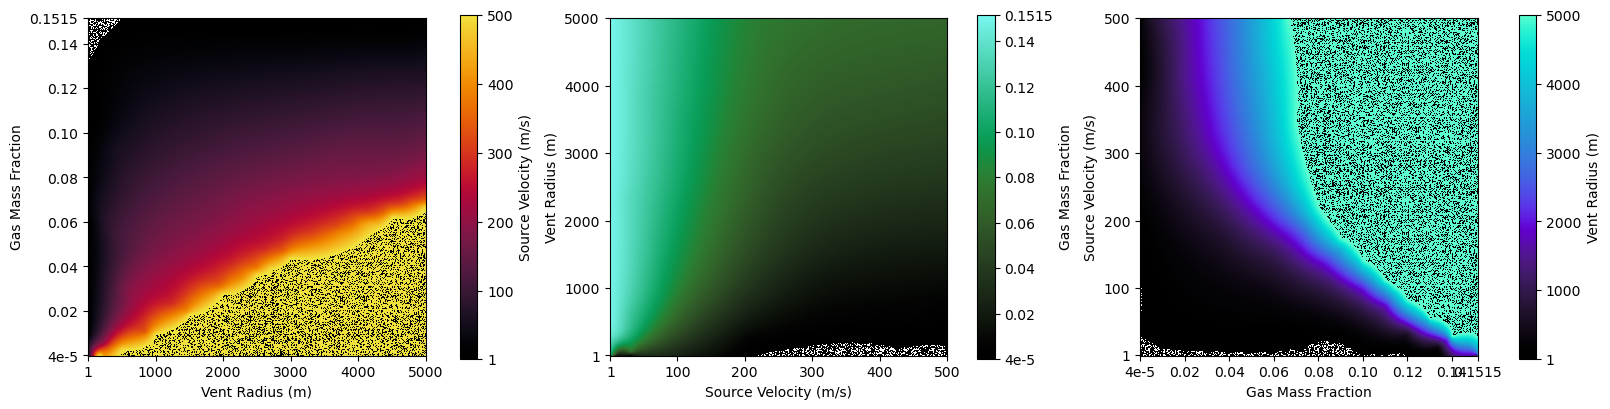

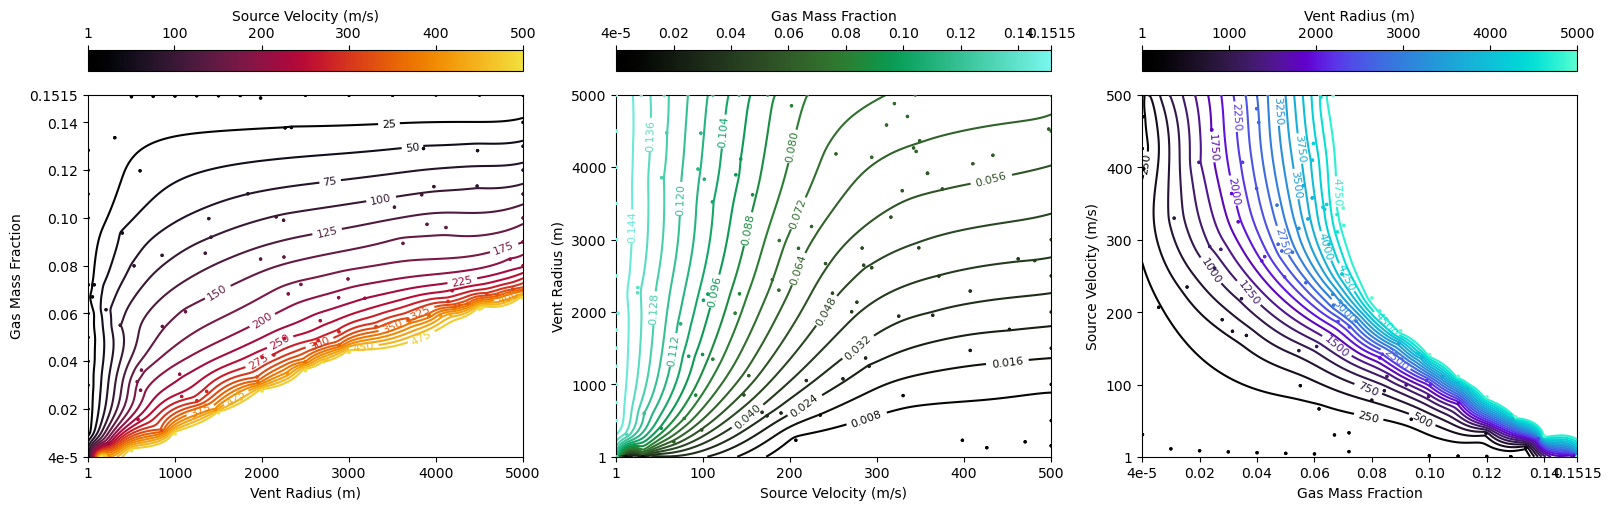

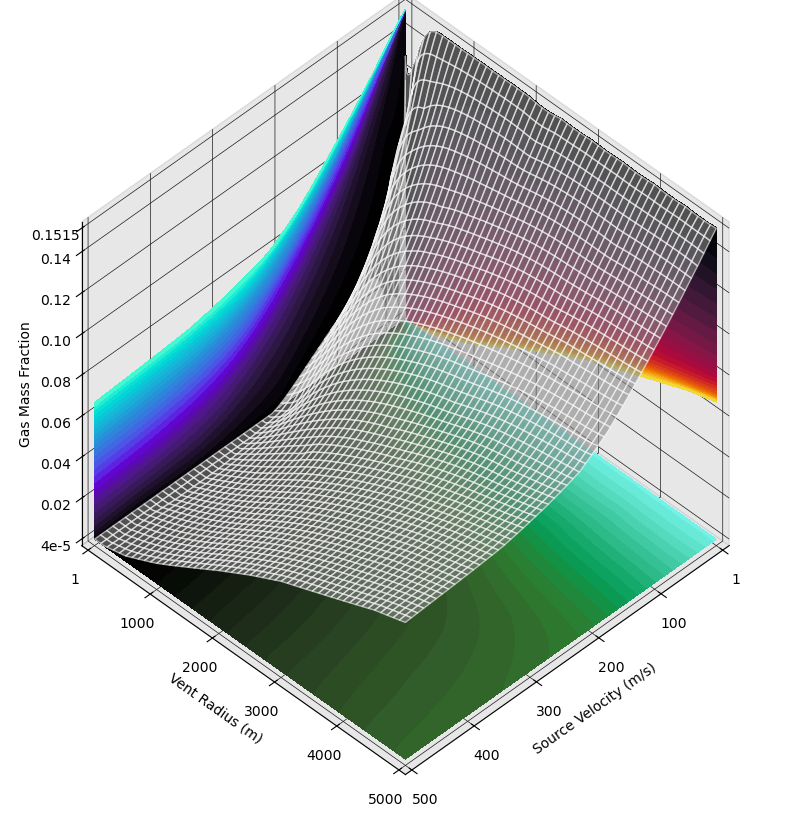

In [379]:
%matplotlib inline
# plots 
f1,a1=Figure_grouped_imshow()
# Figure_individual_imshow()
#Figure_individual_contour()
# Figure_grouped_contour()
f2,a2=Figure_grouped_contour_scatter() #this more lines
f3,a3 = Figure_3D_cmaps_solid(1)
nm=f'{xar["mode"]}-{xar["kernel"]}-sm{xar["smoothing"]}-e{xar["epsilon"]}-d{xar["degree"]}'
for fig in (f1,f2,f3):
    fig.suptitle(xar)
f1.savefig(f'grouped_imsh-{nm}.png', dpi=240, bbox_inches='tight')
f2.savefig(f'grouped_contsc-{nm}.png', dpi=240, bbox_inches='tight')
f3.savefig(f'3D_solid-{nm}.png', dpi=240, bbox_inches='tight')






C:\Users\willr\AppData\Local\Temp\ipykernel_26692\566025543.py:200: UserWarning: The following kwargs were not used by contour: 'stride'
  cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]


(<Figure size 1600x1000 with 1 Axes>,
 <Axes3D: xlabel='Source Velocity (m/s)', ylabel='Vent Size (m)', zlabel='Gas Mass Fraction'>)

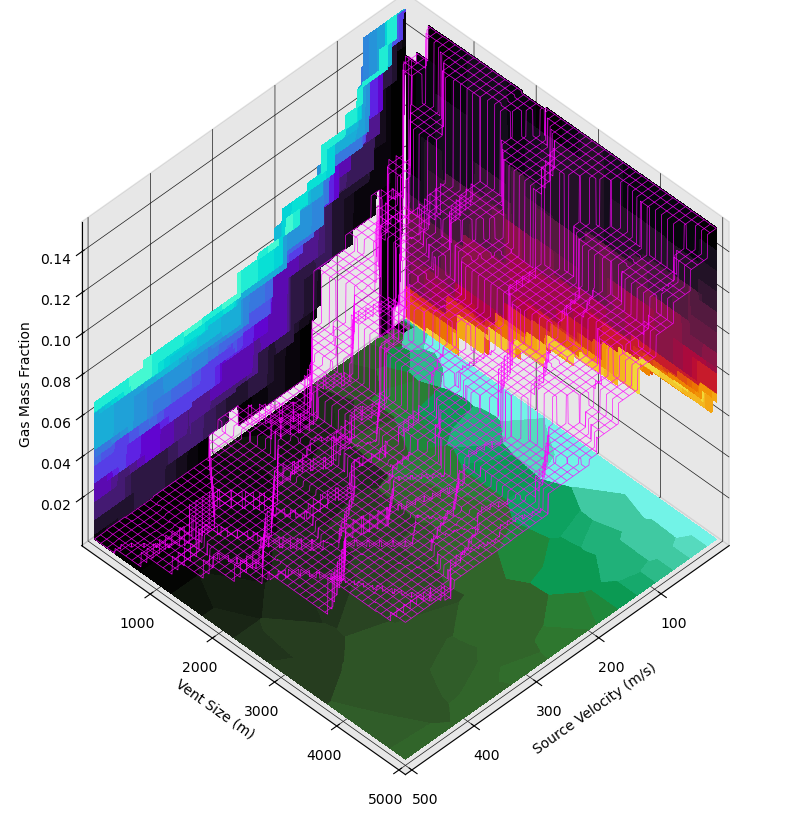

In [94]:
%matplotlib inline
# 3d plots
# Figure_3D_contourlines(0)
# Figure_3D_cmaps_solid(1)
Figure_3D_cmaps_wireframe(1)


C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:202: UserWarning: The following kwargs were not used by contour: 'stride'
  cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:202: UserWarning: The following kwargs were not used by contour: 'stride'
  cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:202: UserWarning: The following kwargs were not used by contour: 'stride'
  cfx,cfy,cfz = [ax3d.contourf(*v[n], zdir=n, cmap=cmap[i], **kws) for i,n in enumerate(('x','y','z'))]


[1, 100.0, 200.0, 300.0, 400.0, 500.0] ['1', '100', '200', '300', '400', '500']
[4e-05, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12000000000000001, 0.14, 0.1515] ['4e-5', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14', '0.1515']
[1, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0] ['1', '1000', '2000', '3000', '4000', '5000']
[1, 100.0, 200.0, 300.0, 400.0, 500.0] ['1', '100', '200', '300', '400', '500']
[4e-05, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12000000000000001, 0.14, 0.1515] ['4e-5', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14', '0.1515']
[1, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0] ['1', '1000', '2000', '3000', '4000', '5000']
[1, 100.0, 200.0, 300.0, 400.0, 500.0] ['1', '100', '200', '300', '400', '500']
[4e-05, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12000000000000001, 0.14, 0.1515] ['4e-5', '0.02', '0.04', '0.06', '0.08', '0.10', '0.12', '0.14', '0.1515']
[1, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0] ['1', '1000', '2000', '3000', '4000', '5000']


C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:254: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:254: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:254: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ipykernel_26692\2761774820.py:254: UserWarning: The following kwargs were not used by contour: 'offset', 'stride'
  ctr = ax.contour(x['v'],y['v'],z['v'], cmap=cmap, norm=norm,**kwupdated(kwargs,'contour'))
C:\Users\willr\AppData\Local\Temp\ip

({'grpcontsc_rows_25_cubic': <Figure size 2000x625 with 6 Axes>,
  'grpcontsc_rows_10_cubic': <Figure size 2000x625 with 6 Axes>,
  'grpcontsc_cols_25_cubic': <Figure size 750x1500 with 6 Axes>,
  'grpcontsc_cols_10_cubic': <Figure size 750x1500 with 6 Axes>},
 {'grpcontsc_rows_25_cubic': <Axes: xlabel='Gas Mass Fraction', ylabel='Source Velocity (m/s)'>,
  'grpcontsc_rows_10_cubic': <Axes: xlabel='Gas Mass Fraction', ylabel='Source Velocity (m/s)'>,
  'grpcontsc_cols_25_cubic': <Axes: xlabel='Gas Mass Fraction', ylabel='Source Velocity (m/s)'>,
  'grpcontsc_cols_10_cubic': <Axes: xlabel='Gas Mass Fraction', ylabel='Source Velocity (m/s)'>})